In [1]:
import pickle
import os, sys
import numpy as np
import pandas as pd
from pathlib import Path
from time import process_time
from collections import defaultdict

from prod_fs import ProD

In [2]:
dataset_name = "ADDERdiscrete"

nRetainedFeatures = 10 # Top 10 % of 100 (Canedo, 2012)

with open(Path("ADDERdiscrete_datasets.pkl"), "rb") as handle:
    synthetic_datasets = pickle.load(handle)

In [3]:
ADDER_D_30 = synthetic_datasets[30][0]
X = ADDER_D_30['X']
y = ADDER_D_30['y']

In [4]:
print(X)
print(X.shape)

[[0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 0]
 ...
 [0 1 1 ... 0 1 0]
 [1 0 0 ... 1 1 0]
 [1 0 1 ... 0 1 0]]
(30, 100)


In [5]:
print(y)
print(y.shape)

[1 1 1 2 2 2 2 2 2 3 3 3 2 2 2 3 3 3 3 3 3 4 4 4 1 2 2 3 2 3]
(30,)


In [6]:
# Proposed algorithm
prodRankerSilverman = ProD(
    integration_method="trapz", delta=500, bw_method="customSilverman",
    k=4, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5
)
prodRankerSilverman.fit(X, y)

top10Features_Silverman = prodRankerSilverman.get_topnFeatures(10)
print(f"Silverman Top Ranked Features: {top10Features_Silverman}")

# Proposed algorithm
prodRankerScott = ProD(
    integration_method="trapz", delta=500, bw_method="customScott",
    k=4, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5
)
prodRankerScott.fit(X, y)

top10Features_Scott = prodRankerScott.get_topnFeatures(10)
print(f"Scott Top Ranked Features: {top10Features_Scott}")

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Silverman Top Ranked Features: [0, 1, 2, 3, 4, 5, 21, 69, 6, 7]
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Scott Top Ranked Features: [0, 1, 2, 3, 4, 5, 21, 69, 66, 83]


/home/liaw/repo/prod-fs/src/prod_fs/prodfs.py:248: RuntimeWarning: divide by zero encountered in divide
  self.feature_importances_ = 1/self.intersectionAreas


Text(0.5, 0.98, 'Silverman')

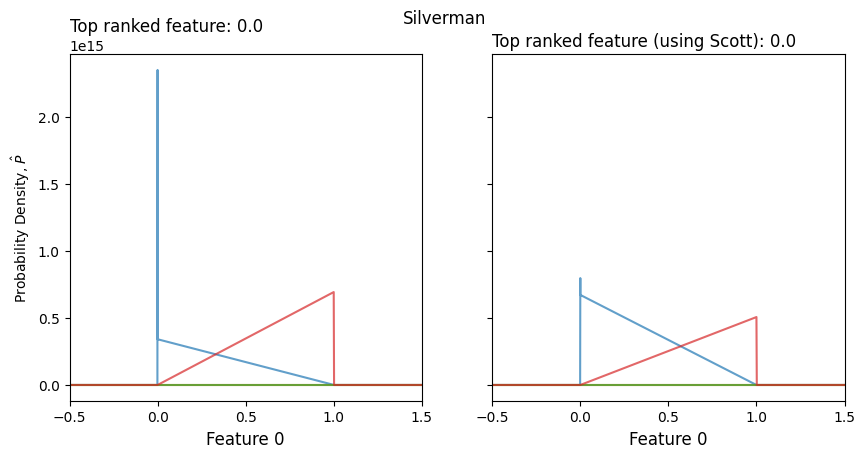

In [7]:
# ADDER
# - Relevant   : 0, 1, 2
# - Redundant  : 3, 4, 5
# - Correlated : 6, 7

# Visualize the top feature's ability to segregate PDEs
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4.5))

fRank = 0

# Top ranked feature from Silverman
prodRankerSilverman.plot_overlapAreas(top10Features_Silverman[fRank], legend=False, _ax=axs[0])
axs[0].set_title(
    f"Top ranked feature: {round(prodRankerSilverman.intersectionAreas[top10Features_Silverman[fRank]], 3)}", 
    loc="left"
)

# Top ranked feature from Silverman but using Scott
prodRankerScott.plot_overlapAreas(top10Features_Silverman[fRank], legend=False, _ax=axs[1])
axs[1].set_title(
    f"Top ranked feature (using Scott): {round(prodRankerScott.intersectionAreas[top10Features_Silverman[fRank]], 3)}", 
    loc="left"
)

axs[0].set_ylabel(r"Probability Density, $\hat{P}$")
for i in range(2):
    axs[i].set_xlim(-0.5, 1.5)
    axs[i].set_xticks(np.arange(-0.5, 2.0, 0.5))

plt.suptitle("Silverman")

Text(0.5, 0.98, 'Silverman')

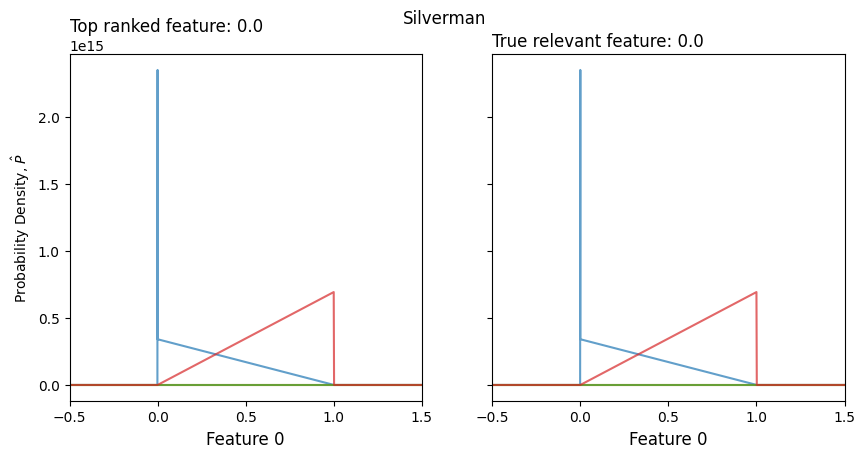

In [8]:
# ADDER
# - Relevant   : 0, 1, 2
# - Redundant  : 3, 4, 5
# - Correlated : 6, 7

fRank = 0

# Visualize the top feature's ability to segregate PDEs
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4.5))

# Top ranked feature
prodRankerSilverman.plot_overlapAreas(top10Features_Silverman[fRank], legend=False, _ax=axs[0])
axs[0].set_title(
    f"Top ranked feature: {round(prodRankerSilverman.intersectionAreas[top10Features_Silverman[fRank]], 3)}", 
    loc="left"
)

# Last ranked feature
prodRankerSilverman.plot_overlapAreas(0, legend=False, _ax=axs[1])
axs[1].set_title(
    f"True relevant feature: {round(prodRankerSilverman.intersectionAreas[0], 3)}", 
    loc="left"
)

axs[0].set_ylabel(r"Probability Density, $\hat{P}$")
for i in range(2):
    axs[i].set_xlim(-0.5, 1.5)
    axs[i].set_xticks(np.arange(-0.5, 2.0, 0.5))

plt.suptitle("Silverman")